In [1]:
# import matplotlib as mpl
# name = "Accent"
# cmap = mpl.colormaps[name]  # type: matplotlib.colors.ListedColormap
# colors = cmap.colors  # type: list
# # axes.set_prop_cycle(color=colors)
# mpl.axes.Axes.set_prop_cycle(color=colors)

In [2]:
import torch
import matplotlib as mpl
from matplotlib import cm
import numpy as np
from functools import partial
from matplotlib import pyplot as plt
from cycler import cycler

def quad(a,b,c,x): return a*x**2 + b*x + c
def make_quad(a,b,c): return partial(quad, a, b, c)

def plot_function(f, ylim=None, title=None):
    # x = np.linspace(-2, 3, 400)
    x = torch.linspace(-2, 3, steps=400)[:, None]
    cmap = mpl.colormaps["Accent"]
    colors = cmap.colors
    plt.gca().set_prop_cycle(color=colors)

    plt.plot(x, f(x))
    if ylim:
        plt.ylim(ylim)
    if title:
        plt.title(title)
    plt.show()

In [3]:
from numpy.random import normal, seed, uniform
np.random.seed(42)

def noise(x, scale): return normal(scale=scale, size=x.shape)
def add_noise(x, mult, add): return x * (1 + noise(x, mult)) + noise(x, add)
def quad_mse(params):
    f = make_quad(*params)
    return mse(f(x), y)

In [4]:
f = make_quad(3,2,1)
f(1.5)

10.75

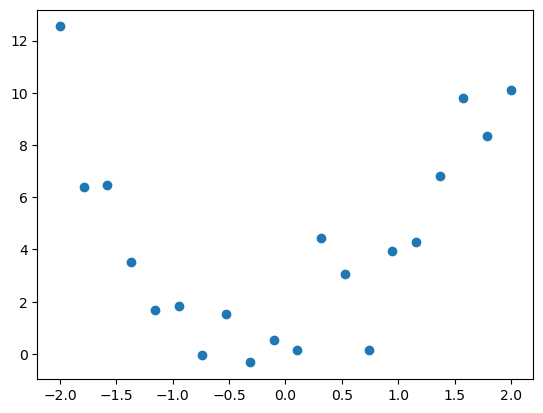

In [5]:
import torch
from matplotlib import pyplot as plt

x = torch.linspace(-2, 2, steps=20)[:, None]
y = add_noise(f(x), 0.3, 1.5)
plt.scatter(x,y)

In [6]:
def mse(preds, acts): return ((preds-acts)**2).mean()

In [7]:
from ipywidgets import interact

@interact(a=1.5,b=1.5,c=1.5)
def plot_quad(a,b,c):
    f = make_quad(a,b,c)
    plt.scatter(x,y)
    loss = mse(f(x),y)
    plot_function(f, ylim=[-3, 12], title=f"MSE: {loss:0.2f}")
    #plt.show()

interactive(children=(FloatSlider(value=1.5, description='a', max=4.5, min=-1.5), FloatSlider(value=1.5, descr…

In [8]:
quad_mse([1.5, 1.5, 1.5])

tensor(5.8336, dtype=torch.float64)

In [9]:
abc = torch.tensor([1.5, 1.5, 1.5])
abc.requires_grad_()

tensor([1.5000, 1.5000, 1.5000], requires_grad=True)

In [10]:
loss = quad_mse(abc)
loss

tensor(5.8336, dtype=torch.float64, grad_fn=<MeanBackward0>)

In [11]:
loss.backward()
abc.grad

tensor([-5.1419,  2.8472, -1.1009])

In [12]:
for i in range(5):
    loss = quad_mse(abc)
    loss.backward()
    with torch.no_grad(): abc -= abc.grad *0.01
    print(f"MSE {loss}")

MSE 5.833613174699768
MSE 5.171593784793668
MSE 4.408906719560048
MSE 3.755386372820574
MSE 3.3723289480810825


In [13]:
def rectified_linear(m,b,x):
    y = m*x + b
    return torch.clip(torch.tensor(y), 0.)

In [14]:
partial(rectified_linear,1,1)(1)

tensor(2.)

/tmp/ipykernel_1989/3212343948.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.clip(torch.tensor(y), 0.)


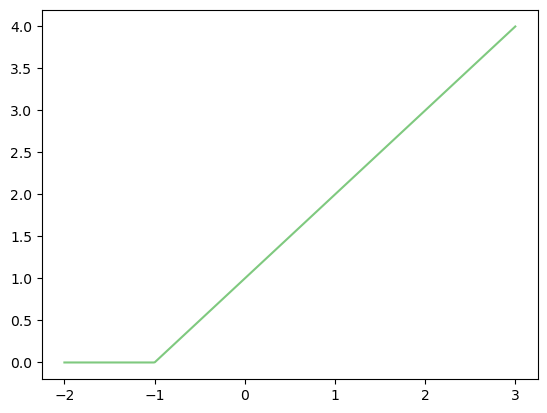

In [15]:
plot_function(partial(rectified_linear,1,1))

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

def plot_poly(degree, x, y):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(x, y)
    plt.scatter(x, y)
    plot_function(model.predict)

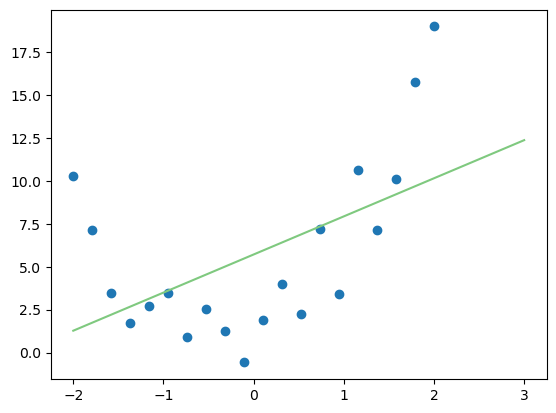

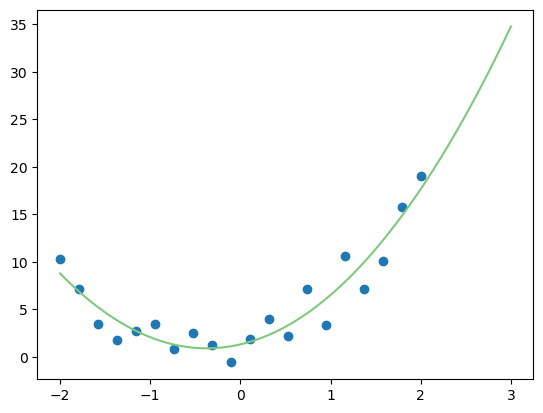

In [17]:
x = torch.linspace(-2, 2, steps=20)[:, None]
y = add_noise(f(x), 0.3, 1.5)
plot_poly(1, x, y)
plot_poly(2, x, y)

In [18]:
!ls -la .git*

-rw-rw-r-- 1 1000 1000  105 Jan 23 19:33 .gitignore

.git:
total 152
drwxrwxr-x  7 1000 1000  4096 Mar 14 21:32 .
drwxrwxr-x 13 1000 1000  4096 Mar 15 18:09 ..
-rw-rw-r--  1 1000 1000    22 Mar 14 21:32 COMMIT_EDITMSG
-rw-rw-r--  1 1000 1000    37 Feb 22 15:49 HEAD
-rw-rw-r--  1 1000 1000   643 Feb 22 15:54 config
-rw-rw-r--  1 1000 1000    73 Jan 23 19:33 description
-rw-rw-r--  1 1000 1000 54591 Feb 23 20:55 gitk.cache
drwxrwxr-x  2 1000 1000  4096 Jan 23 19:33 hooks
-rw-r--r--  1 root root 47472 Mar 14 21:32 index
drwxrwxr-x  2 1000 1000  4096 Jan 23 19:33 info
drwxrwxr-x  3 1000 1000  4096 Jan 23 19:33 logs
drwxrwxr-x 55 1000 1000  4096 Mar 14 21:32 objects
-rw-rw-r--  1 1000 1000   295 Jan 23 19:33 packed-refs
drwxrwxr-x  5 1000 1000  4096 Jan 23 19:33 refs
